<a href="https://colab.research.google.com/github/BoodiElMadkhoum/Data-Mining-Defect-Prediction/blob/main/Data_Mining_PRoject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


dataset = fetch_openml(name='jm1', version=1, as_frame=True, parser='auto')
df = dataset.frame


df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Separate the dataset into Features (X) by dropping the target column
X = df.drop('defects', axis=1)
# Ensure all feature columns are strictly numeric (converting from object types if necessary)
X = X.apply(pd.to_numeric)

# SAFELY convert the target column (y) to binary integers.
# OpenML loads these as 'true'/'false' strings. This lambda checks the string and outputs 1 or 0.
y = df['defects'].apply(lambda val: 1 if str(val).strip().lower() == 'true' else 0)

# Initialize the StandardScaler object
scaler = StandardScaler()
# Fit the scaler to the features and transform them into scaled numerical values
X_scaled = scaler.fit_transform(X)
# Convert the resulting numpy array back into a DataFrame, keeping the original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Initialize the SMOTE object with a fixed random state for reproducibility
smote = SMOTE(random_state=42)
# Apply SMOTE to generate synthetic defective samples, balancing the dataset classes
X_balanced, y_balanced = smote.fit_resample(X_scaled_df, y)

# Split the balanced data: 80% for training the model, 20% for testing its performance
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1759
           1       0.89      0.90      0.90      1752

    accuracy                           0.90      3511
   macro avg       0.90      0.90      0.90      3511
weighted avg       0.90      0.90      0.90      3511



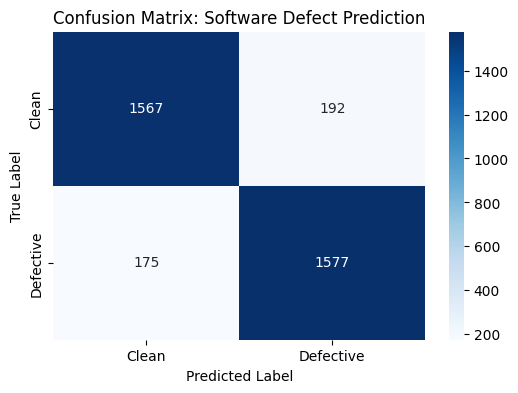

/tmp/ipykernel_1320/741006654.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


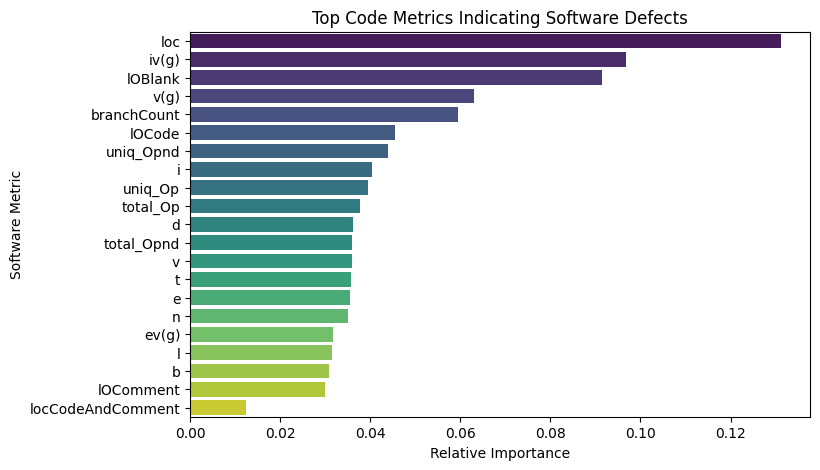

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Random Forest model with 100 decision trees and a fixed random state
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Train (fit) the model using the balanced training features and training labels
rf_model.fit(X_train, y_train)

# Use the trained model to predict defect labels for the unseen test features
y_pred = rf_model.predict(X_test)

# Print a header for the evaluation report
print("--- Model Performance Report ---")
# Print Precision, Recall, F1-Score, and Accuracy metrics
print(classification_report(y_test, y_pred))

# Generate the confusion matrix array to see true positives, false positives, etc.
cm = confusion_matrix(y_test, y_pred)

# Create a new matplotlib figure with a specific size (6x4 inches)
plt.figure(figsize=(6, 4))
# Plot the confusion matrix as a heatmap with blue color scaling
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean', 'Defective'], yticklabels=['Clean', 'Defective'])
# Set the title of the heatmap plot
plt.title('Confusion Matrix: Software Defect Prediction')
# Label the axes
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
# Render and display the confusion matrix plot
plt.show()

# Extract the calculated importance score for each feature from the trained model
importances = rf_model.feature_importances_
# Create a DataFrame pairing each feature name with its importance score
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
# Sort the DataFrame in descending order based on the importance score
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Create a new matplotlib figure (8x5 inches) for the bar plot
plt.figure(figsize=(8, 5))
# Plot a horizontal bar chart showing feature importances
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
# Set the title and labels for the feature importance plot
plt.title('Top Code Metrics Indicating Software Defects')
plt.xlabel('Relative Importance')
plt.ylabel('Software Metric')
# Render and display the plot
plt.show()